# PayBack — Recovery Probability Model v3 (Deployment-Safe)

This version keeps the same synthetic benchmark idea but exports the model in a format that is safer to integrate into PayBack.

Key changes from v2:

- Explicit categorical encoding instead of a scikit-learn `ColumnTransformer`
- XGBoost model saved in native JSON format
- Calibration parameters saved as plain JSON
- Feature schema and category mappings saved as JSON
- Inference can be implemented with NumPy + XGBoost without depending on the training environment's scikit-learn version

Target:

`P(revenue is recovered | decision-time context)`

All benchmark results are synthetic and are not production performance claims.

In [16]:
!pip -q install -U xgboost==3.0.2 joblib

In [17]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

SEED = 42
N_CASES = 100_000
MANUAL_CASES = 50

np.random.seed(SEED)
random.seed(SEED)
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("/kaggle/working/payback_ml")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output:", OUTPUT_DIR)

Output: /kaggle/working/payback_ml


## 1. Generate synthetic decision-time data

In [18]:
payment_methods = ["upi", "card", "netbanking", "wallet"]
failure_types = [
    "temporary_bank_error",
    "timeout",
    "insufficient_funds",
    "expired_instrument",
    "authentication_failure",
    "unknown",
]

df = pd.DataFrame({
    "case_id": [f"RC{idx:07d}" for idx in range(N_CASES)],
    "amount": np.round(rng.lognormal(np.log(1800), 0.85, N_CASES), 2),
    "payment_method": rng.choice(payment_methods, N_CASES, p=[0.45, 0.34, 0.13, 0.08]),
    "failure_type": rng.choice(
        failure_types, N_CASES, p=[0.23, 0.21, 0.18, 0.11, 0.15, 0.12]
    ),
    "checkout_intent_score": np.round(rng.beta(4.5, 2.2, N_CASES), 4),
    "customer_tenure_days": rng.integers(1, 1500, N_CASES),
    "previous_transactions": rng.poisson(9, N_CASES),
    "previous_failures": rng.poisson(1.4, N_CASES),
    "previous_recoveries": rng.poisson(2.1, N_CASES),
    "days_since_failure": rng.integers(0, 15, N_CASES),
    "retry_count": rng.integers(0, 4, N_CASES),
    "messages_sent": rng.integers(0, 4, N_CASES),
    "opted_out": rng.binomial(1, 0.035, N_CASES),
})

df["previous_transactions"] = np.maximum(
    df["previous_transactions"],
    df["previous_failures"] + df["previous_recoveries"],
)

df["historical_success_rate"] = np.clip(
    (
        df["previous_transactions"]
        - df["previous_failures"]
        + rng.normal(0, 1.0, N_CASES)
    ) / np.maximum(df["previous_transactions"], 1),
    0,
    1,
)

df["prior_recovery_rate"] = np.clip(
    (
        df["previous_recoveries"]
        + rng.normal(0, 0.7, N_CASES)
    ) / np.maximum(
        df["previous_failures"] + df["previous_recoveries"], 1
    ),
    0,
    1,
)

df["high_value"] = (df["amount"] >= 10_000).astype(int)
df["customer_history_strength"] = np.clip(
    np.log1p(df["previous_transactions"]) / np.log1p(40),
    0,
    1,
)

In [19]:
# Stochastic, nonlinear hidden ground truth.
score = (
    -1.05
    + 2.40 * df["checkout_intent_score"]
    + 1.40 * df["historical_success_rate"]
    + 0.90 * df["prior_recovery_rate"]
    + 0.55 * df["customer_history_strength"]
    - 0.21 * np.log1p(df["amount"])
    - 0.20 * df["previous_failures"]
    - 0.34 * df["retry_count"]
    - 0.18 * df["messages_sent"]
    - 0.12 * df["days_since_failure"]
    - 2.60 * df["opted_out"]
)

score += np.select(
    [
        df["failure_type"].eq("temporary_bank_error"),
        df["failure_type"].eq("timeout"),
        df["failure_type"].eq("insufficient_funds"),
        df["failure_type"].eq("expired_instrument"),
        df["failure_type"].eq("authentication_failure"),
    ],
    [0.95, 0.65, -0.45, -0.75, -0.50],
    default=0.0,
)

score += np.where(df["payment_method"].eq("upi"), 0.12, 0.0)
score += np.where(df["payment_method"].eq("card"), 0.04, 0.0)

score += np.where(
    (df["checkout_intent_score"] > 0.80)
    & (df["historical_success_rate"] > 0.80),
    0.90,
    0.0,
)

score += np.where(
    (df["customer_tenure_days"] > 180)
    & (df["previous_transactions"] >= 10)
    & (df["prior_recovery_rate"] > 0.50),
    0.55,
    0.0,
)

score += np.where(
    (df["retry_count"] == 0)
    & (df["days_since_failure"] <= 1)
    & (df["failure_type"].isin(["temporary_bank_error", "timeout"])),
    0.45,
    0.0,
)

score += np.where(
    (df["amount"] > 10_000)
    & (df["checkout_intent_score"] < 0.40),
    -0.40,
    0.0,
)

score += np.where(df["opted_out"].eq(1), -3.5, 0.0)

true_probability = 1 / (1 + np.exp(-score))
df["recovered"] = rng.binomial(1, true_probability)

print("Synthetic recovery rate:", round(float(df["recovered"].mean()), 4))

Synthetic recovery rate: 0.4003


## 2. Explicit feature encoding

The encoding is deliberately simple and fully reproducible.

Instead of saving a scikit-learn preprocessing object, we store:

- ordered numeric feature list
- ordered categories
- one-hot mapping

This makes the production feature adapter straightforward and version-stable.

In [20]:
numeric_features = [
    "amount",
    "checkout_intent_score",
    "customer_tenure_days",
    "previous_transactions",
    "historical_success_rate",
    "previous_failures",
    "previous_recoveries",
    "days_since_failure",
    "retry_count",
    "messages_sent",
    "opted_out",
    "high_value",
    "prior_recovery_rate",
    "customer_history_strength",
]

categorical_features = ["payment_method", "failure_type"]

feature_schema = {
    "version": "payback-recovery-v3",
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categories": {
        "payment_method": payment_methods,
        "failure_type": failure_types,
    },
    "target": "recovered",
}

def encode_features(frame):
    pieces = [
        frame[numeric_features].astype(float).to_numpy()
    ]

    for column in categorical_features:
        values = frame[column].astype(str).to_numpy()
        categories = feature_schema["categories"][column]
        encoded = np.column_stack([
            (values == category).astype(float)
            for category in categories
        ])
        pieces.append(encoded)

    return np.concatenate(pieces, axis=1)

encoded = encode_features(df)

print("Encoded shape:", encoded.shape)

Encoded shape: (100000, 24)


## 3. Train / validation / test split

In [21]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=df["recovered"],
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=df["recovered"].iloc[temp_idx],
)

X_train = encoded[train_idx]
X_val = encoded[val_idx]
X_test = encoded[test_idx]

y_train = df["recovered"].to_numpy()[train_idx]
y_val = df["recovered"].to_numpy()[val_idx]
y_test = df["recovered"].to_numpy()[test_idx]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (70000, 24)
Validation: (15000, 24)
Test: (15000, 24)


## 4. Logistic Regression baseline

In [22]:
logistic = LogisticRegression(
    max_iter=1500,
    random_state=SEED,
)

logistic.fit(X_train, y_train)
val_lr = logistic.predict_proba(X_val)[:, 1]

print("Validation ROC-AUC:", round(roc_auc_score(y_val, val_lr), 5))
print("Validation PR-AUC:", round(average_precision_score(y_val, val_lr), 5))
print("Validation Brier:", round(brier_score_loss(y_val, val_lr), 5))

Validation ROC-AUC: 0.8026
Validation PR-AUC: 0.72707
Validation Brier: 0.17597


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. XGBoost main model

In [23]:
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_lambda=1.0,
    reg_alpha=0.10,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

val_xgb = xgb.predict_proba(X_val)[:, 1]

print("Validation ROC-AUC:", round(roc_auc_score(y_val, val_xgb), 5))
print("Validation PR-AUC:", round(average_precision_score(y_val, val_xgb), 5))
print("Validation Brier:", round(brier_score_loss(y_val, val_xgb), 5))

Validation ROC-AUC: 0.81193
Validation PR-AUC: 0.74044
Validation Brier: 0.17172


## 6. Lightweight probability calibration

Instead of saving a scikit-learn calibration wrapper, store the calibration model's two parameters as JSON.

This gives us a very small, deployment-friendly artifact.

In [24]:
def safe_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p), eps, 1 - eps)
    return np.log(p / (1 - p))

calibrator = LogisticRegression(max_iter=1000, random_state=SEED)
calibrator.fit(safe_logit(val_xgb).reshape(-1, 1), y_val)

calibration_coef = float(calibrator.coef_[0, 0])
calibration_intercept = float(calibrator.intercept_[0])

def calibrate_probability(raw_probability):
    z = calibration_coef * safe_logit(raw_probability) + calibration_intercept
    return 1 / (1 + np.exp(-z))

val_xgb_calibrated = calibrate_probability(val_xgb)

print("Calibration coefficient:", calibration_coef)
print("Calibration intercept:", calibration_intercept)
print(
    "Calibrated validation Brier:",
    round(brier_score_loss(y_val, val_xgb_calibrated), 5),
)

Calibration coefficient: 0.9540740845599085
Calibration intercept: -0.01725399436142655
Calibrated validation Brier: 0.17167


## 7. Held-out test evaluation

In [25]:
test_lr = logistic.predict_proba(X_test)[:, 1]
test_xgb = xgb.predict_proba(X_test)[:, 1]
test_xgb_calibrated = calibrate_probability(test_xgb)

def evaluate(name, probability, y_true):
    prediction = (probability >= 0.50).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "brier_score": brier_score_loss(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
    }

results = pd.DataFrame([
    evaluate("logistic_regression", test_lr, y_test),
    evaluate("xgboost", test_xgb, y_test),
    evaluate("xgboost_calibrated", test_xgb_calibrated, y_test),
])

results = results.sort_values(
    ["pr_auc", "brier_score"],
    ascending=[False, True],
).reset_index(drop=True)

results

,model,roc_auc,pr_auc,brier_score,log_loss,accuracy,precision,recall,f1
0,xgboost,0.811179,0.740744,0.172072,0.513820,0.742533,0.698333,0.628081,0.661347
1,xgboost_calibrated,0.811179,0.740744,0.171992,0.513595,0.741933,0.700357,0.620919,0.658250
2,logistic_regression,0.802307,0.728612,0.176027,0.524072,0.729933,0.678944,0.617089,0.646540


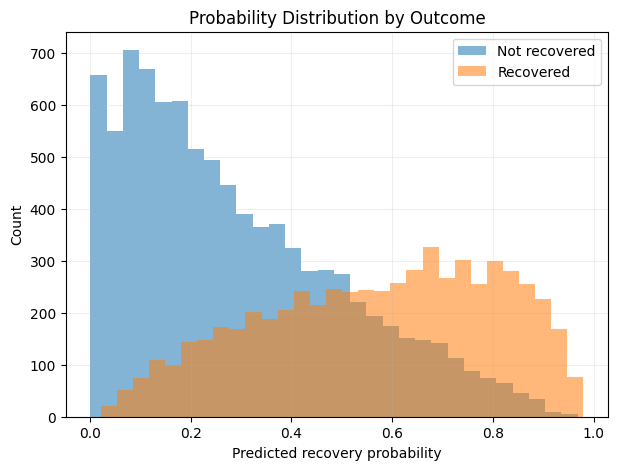

In [26]:
plt.figure(figsize=(7, 5))

plt.hist(
    test_xgb_calibrated[y_test == 0],
    bins=30,
    alpha=0.55,
    label="Not recovered",
)
plt.hist(
    test_xgb_calibrated[y_test == 1],
    bins=30,
    alpha=0.55,
    label="Recovered",
)

plt.xlabel("Predicted recovery probability")
plt.ylabel("Count")
plt.title("Probability Distribution by Outcome")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. 50-case manual test set

In [27]:
manual = pd.DataFrame([
    {
        "case_label": "strong_temporary_failure",
        "amount": 2499,
        "payment_method": "upi",
        "failure_type": "temporary_bank_error",
        "checkout_intent_score": 0.95,
        "customer_tenure_days": 420,
        "previous_transactions": 18,
        "historical_success_rate": 0.94,
        "previous_failures": 1,
        "previous_recoveries": 2,
        "days_since_failure": 0,
        "retry_count": 0,
        "messages_sent": 0,
        "opted_out": 0,
        "high_value": 0,
        "prior_recovery_rate": 0.67,
        "customer_history_strength": 1.0,
    },
    {
        "case_label": "customer_opted_out",
        "amount": 2499,
        "payment_method": "upi",
        "failure_type": "timeout",
        "checkout_intent_score": 0.10,
        "customer_tenure_days": 700,
        "previous_transactions": 20,
        "historical_success_rate": 0.90,
        "previous_failures": 1,
        "previous_recoveries": 1,
        "days_since_failure": 1,
        "retry_count": 0,
        "messages_sent": 0,
        "opted_out": 1,
        "high_value": 0,
        "prior_recovery_rate": 0.50,
        "customer_history_strength": 1.0,
    },
    {
        "case_label": "repeated_failures",
        "amount": 8000,
        "payment_method": "card",
        "failure_type": "authentication_failure",
        "checkout_intent_score": 0.55,
        "customer_tenure_days": 30,
        "previous_transactions": 5,
        "historical_success_rate": 0.35,
        "previous_failures": 4,
        "previous_recoveries": 0,
        "days_since_failure": 5,
        "retry_count": 2,
        "messages_sent": 2,
        "opted_out": 0,
        "high_value": 0,
        "prior_recovery_rate": 0.05,
        "customer_history_strength": 0.5,
    },
    {
        "case_label": "new_customer_ambiguous",
        "amount": 1500,
        "payment_method": "netbanking",
        "failure_type": "unknown",
        "checkout_intent_score": 0.60,
        "customer_tenure_days": 2,
        "previous_transactions": 0,
        "historical_success_rate": 0.50,
        "previous_failures": 0,
        "previous_recoveries": 0,
        "days_since_failure": 1,
        "retry_count": 0,
        "messages_sent": 0,
        "opted_out": 0,
        "high_value": 0,
        "prior_recovery_rate": 0.50,
        "customer_history_strength": 0.0,
    },
])

manual_rng = np.random.default_rng(123)
remaining = MANUAL_CASES - len(manual)

if remaining > 0:
    extra = pd.DataFrame({
        "case_label": [f"generated_{i:02d}" for i in range(remaining)],
        "amount": np.round(manual_rng.lognormal(np.log(1800), 0.85, remaining), 2),
        "payment_method": manual_rng.choice(payment_methods, remaining),
        "failure_type": manual_rng.choice(failure_types, remaining),
        "checkout_intent_score": np.round(manual_rng.beta(4.5, 2.2, remaining), 4),
        "customer_tenure_days": manual_rng.integers(1, 1500, remaining),
        "previous_transactions": manual_rng.poisson(9, remaining),
        "historical_success_rate": manual_rng.uniform(0.2, 1.0, remaining),
        "previous_failures": manual_rng.poisson(1.4, remaining),
        "previous_recoveries": manual_rng.poisson(2.1, remaining),
        "days_since_failure": manual_rng.integers(0, 15, remaining),
        "retry_count": manual_rng.integers(0, 4, remaining),
        "messages_sent": manual_rng.integers(0, 4, remaining),
        "opted_out": manual_rng.binomial(1, 0.05, remaining),
        "prior_recovery_rate": manual_rng.uniform(0, 1, remaining),
    })
    extra["high_value"] = (extra["amount"] >= 10_000).astype(int)
    extra["customer_history_strength"] = np.clip(
        np.log1p(extra["previous_transactions"]) / np.log1p(40),
        0,
        1,
    )
    manual = pd.concat([manual, extra], ignore_index=True)

manual_encoded = encode_features(manual)
manual_raw = xgb.predict_proba(manual_encoded)[:, 1]
manual_final = calibrate_probability(manual_raw)

manual_results = manual[["case_label"]].copy()
manual_results["raw_xgboost_probability"] = manual_raw
manual_results["final_probability"] = manual_final

manual_results

,case_label,raw_xgboost_probability,final_probability
0,strong_temporary_failure,0.981107,0.977051
1,customer_opted_out,0.006071,0.007530
2,repeated_failures,0.025896,0.029943
3,new_customer_ambiguous,0.498276,0.494042
4,generated_00,0.296472,0.301172
5,generated_01,0.266358,0.272119
6,generated_02,0.027144,0.031312
7,generated_03,0.172749,0.180704
8,generated_04,0.145266,0.153412
9,generated_05,0.393480,0.394105


## 9. Feature importance

In [28]:
# Encoded feature names are deterministic.
feature_names = numeric_features.copy()

for column in categorical_features:
    feature_names.extend([
        f"{column}={category}"
        for category in feature_schema["categories"][column]
    ])

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb.feature_importances_,
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
10,opted_out,0.208068
18,failure_type=temporary_bank_error,0.122258
19,failure_type=timeout,0.120282
7,days_since_failure,0.061631
8,retry_count,0.057647
5,previous_failures,0.045402
1,checkout_intent_score,0.044683
4,historical_success_rate,0.043430
21,failure_type=expired_instrument,0.040588
12,prior_recovery_rate,0.036025


## 10. Export deployment-safe artifacts

In [29]:
model_path = OUTPUT_DIR / "payback_xgboost.json"
schema_path = OUTPUT_DIR / "feature_schema.json"
calibration_path = OUTPUT_DIR / "calibration.json"
metadata_path = OUTPUT_DIR / "model_metadata.json"
metrics_path = OUTPUT_DIR / "model_comparison.csv"
manual_path = OUTPUT_DIR / "manual_test_results.csv"

xgb.save_model(str(model_path))

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2)

with open(calibration_path, "w", encoding="utf-8") as f:
    json.dump({
        "method": "sigmoid_on_logit",
        "coefficient": calibration_coef,
        "intercept": calibration_intercept,
    }, f, indent=2)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump({
        "model_version": "payback-recovery-v3",
        "seed": SEED,
        "synthetic_cases": N_CASES,
        "train_cases": len(X_train),
        "validation_cases": len(X_val),
        "test_cases": len(X_test),
        "manual_cases": len(manual),
        "xgboost_version": __import__("xgboost").__version__,
        "synthetic_only": True,
        "production_performance_claim": False,
    }, f, indent=2)

results.to_csv(metrics_path, index=False)
manual_results.to_csv(manual_path, index=False)

print("Exported:")
for p in [
    model_path,
    schema_path,
    calibration_path,
    metadata_path,
    metrics_path,
    manual_path,
]:
    print(p)

Exported:
/kaggle/working/payback_ml/payback_xgboost.json
/kaggle/working/payback_ml/feature_schema.json
/kaggle/working/payback_ml/calibration.json
/kaggle/working/payback_ml/model_metadata.json
/kaggle/working/payback_ml/model_comparison.csv
/kaggle/working/payback_ml/manual_test_results.csv


## 11. PayBack integration contract

Production inference needs only:

- `payback_xgboost.json`
- `feature_schema.json`
- `calibration.json`

Feature construction should mirror `encode_features()` exactly.

Conceptual adapter:

```python
import json
import numpy as np
import xgboost as xgb

class XGBoostRecoveryProbabilityModel:
    def __init__(self, model_path, schema_path, calibration_path):
        self.model = xgb.XGBClassifier()
        self.model.load_model(model_path)

        self.schema = json.load(open(schema_path))
        self.calibration = json.load(open(calibration_path))

    def predict_probability(self, context):
        vector = build_feature_vector(context, self.schema)
        raw = float(self.model.predict_proba(vector)[0, 1])

        eps = 1e-6
        p = np.clip(raw, eps, 1 - eps)
        z = np.log(p / (1 - p))
        z = (
            self.calibration["coefficient"] * z
            + self.calibration["intercept"]
        )

        return float(1 / (1 + np.exp(-z)))
```

The production code should use PayBack's existing `RecoveryProbabilityModel` interface. No Supabase or Razorpay code belongs in the model adapter.

In [30]:
# Final artifact smoke test in Kaggle.
loaded = __import__("xgboost").XGBClassifier()
loaded.load_model(str(model_path))

sample = manual_encoded[:1]
raw = float(loaded.predict_proba(sample)[0, 1])

p = np.clip(raw, 1e-6, 1 - 1e-6)
z = calibration_coef * np.log(p / (1 - p)) + calibration_intercept
final = 1 / (1 + np.exp(-z))

print("Artifact smoke-test probability:", round(float(final), 5))

Artifact smoke-test probability: 0.97705


## 12. Files to move into PayBack later

Copy only these deployment artifacts into the repository:

```text
ml/
├── models/
│   └── payback_xgboost.json
└── artifacts/
    ├── feature_schema.json
    ├── calibration.json
    └── model_metadata.json
```

The 100,000-row synthetic dataset and notebook can remain in Kaggle or be kept under `ml/data/` and `ml/notebooks/` as experiment records.

Do not integrate the model into the backend until the artifact smoke test and version information have been verified.